In [65]:
import pandas as pd


In [66]:
file_path = "../data/returns_sustainability_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

print(df.head())

Dataset Loaded Successfully
   Order_ID Product_ID   User_ID  Order_Date Product_Category  Product_Price  \
0  ORD00000   PROD0169  USER0195  2022-01-14         Clothing        1720.71   
1  ORD00001   PROD0318  USER1469  2022-01-03             Toys         744.06   
2  ORD00002   PROD0427  USER1812  2025-03-16         Clothing         983.68   
3  ORD00003   PROD0323  USER1274  2024-11-06            Books        1855.65   
4  ORD00004   PROD0325  USER0551  2023-06-07  Home Appliances        1770.97   

   Order_Quantity  Discount_Applied Shipping_Method Payment_Method  ...  \
0               2             30.46        Next-Day         Wallet  ...   
1               5             29.62        Next-Day         Wallet  ...   
2               5             47.80         Express         Wallet  ...   
3               2              2.90         Express            COD  ...   
4               5             44.42         Express            COD  ...   

   Return_Status Return_Reason Days_to_R

In [67]:
print("\n===== DATASET DIMENSIONS =====")

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])


===== DATASET DIMENSIONS =====
Rows : 5000
Columns : 23


In [68]:
print("\n===== COLUMN NAMES =====")

print(df.columns.tolist())

print("\n===== DATASET INFO =====")

df.info()


===== COLUMN NAMES =====
['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Product_Category', 'Product_Price', 'Order_Quantity', 'Discount_Applied', 'Shipping_Method', 'Payment_Method', 'User_Age', 'User_Gender', 'User_Location', 'Return_Status', 'Return_Reason', 'Days_to_Return', 'Order_Value', 'Return_Cost', 'Profit_Loss', 'CO2_Emissions', 'Packaging_Waste', 'CO2_Saved', 'Waste_Avoided']

===== DATASET INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   str    
 1   Product_ID        5000 non-null   str    
 2   User_ID           5000 non-null   str    
 3   Order_Date        5000 non-null   str    
 4   Product_Category  5000 non-null   str    
 5   Product_Price     5000 non-null   float64
 6   Order_Quantity    5000 non-null   int64  
 7   Discount_Applied  5000 non-null   float64
 8   Shippi

In [69]:
print("\n===== MISSING VALUES =====")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values :")

print(missing_values.sum())


===== MISSING VALUES =====
Order_ID            0
Product_ID          0
User_ID             0
Order_Date          0
Product_Category    0
Product_Price       0
Order_Quantity      0
Discount_Applied    0
Shipping_Method     0
Payment_Method      0
User_Age            0
User_Gender         0
User_Location       0
Return_Status       0
Return_Reason       0
Days_to_Return      0
Order_Value         0
Return_Cost         0
Profit_Loss         0
CO2_Emissions       0
Packaging_Waste     0
CO2_Saved           0
Waste_Avoided       0
dtype: int64

Total Missing Values :
0


In [70]:
print("\n===== DUPLICATES =====")

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates :", df.shape)


===== DUPLICATES =====
Duplicate Rows : 0
Shape After Removing Duplicates : (5000, 23)


In [71]:
total_orders = len(df)

print("\nTotal Orders :", total_orders)


Total Orders : 5000


In [72]:
returned_products = (

df["Return_Status"]

.astype(str)

.str.strip()

.eq("Returned")

.sum()

)

print("Total Returned Products :", returned_products)

Total Returned Products : 1450


In [73]:
return_percentage = (

returned_products

/ total_orders

) * 100

print(

"Return Percentage :",

round(return_percentage, 2),

"%"

)

Return Percentage : 29.0 %


In [74]:
print("===== MEAN =====")

print("Average Delivery Duration")

print(df["Days_to_Return"].mean())

print("\nAverage Product Price")

print(df["Product_Price"].mean())

===== MEAN =====
Average Delivery Duration
9.2042

Average Product Price
1054.2947399999998


In [75]:
print("===== MEDIAN =====")

print("Delivery Duration Median")

print(df["Days_to_Return"].median())

print("\nProduct Price Median")

print(df["Product_Price"].median())

===== MEDIAN =====
Delivery Duration Median
0.0

Product Price Median
1044.85


In [76]:
print("===== STANDARD DEVIATION =====")

print("Delivery Duration SD")

print(df["Days_to_Return"].std())

print("\nProduct Price SD")

print(df["Product_Price"].std())

===== STANDARD DEVIATION =====
Delivery Duration SD
16.753156001398704

Product Price SD
548.5604061896375


In [77]:
print("===== QUARTILES =====")

print("Delivery Duration Quartiles")

print(
df["Days_to_Return"]
.quantile([0.25,0.50,0.75])
)

print("\nProduct Price Quartiles")

print(
df["Product_Price"]
.quantile([0.25,0.50,0.75])
)

===== QUARTILES =====
Delivery Duration Quartiles
0.25     0.0
0.50     0.0
0.75    12.0
Name: Days_to_Return, dtype: float64

Product Price Quartiles
0.25     580.9375
0.50    1044.8500
0.75    1530.8350
Name: Product_Price, dtype: float64


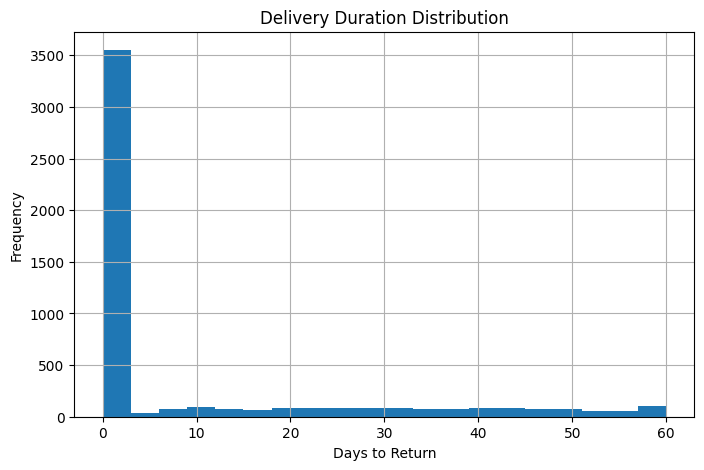

<Figure size 640x480 with 0 Axes>

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["Days_to_Return"].hist(
bins=20
)

plt.title(
"Delivery Duration Distribution"
)

plt.xlabel(
"Days to Return"
)

plt.ylabel(
"Frequency"
)

plt.show()
plt.savefig("../images/Delivery Duration Distribution.png")

plt.show()

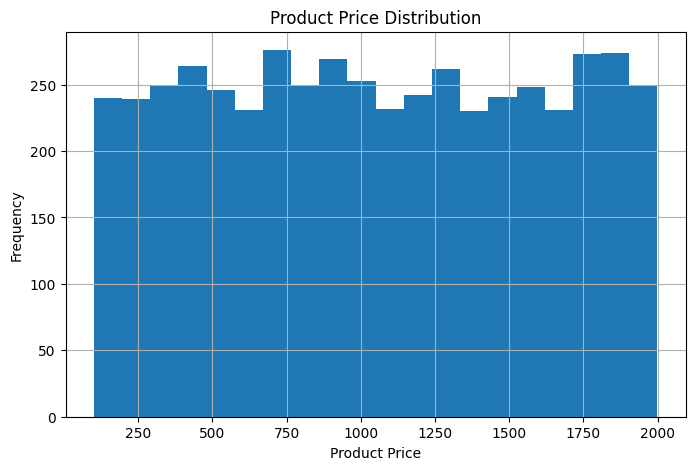

<Figure size 640x480 with 0 Axes>

In [79]:
plt.figure(figsize=(8,5))

df["Product_Price"].hist(
bins=20
)

plt.title(
"Product Price Distribution"
)

plt.xlabel(
"Product Price"
)

plt.ylabel(
"Frequency"
)

plt.show()
plt.savefig("../images/Product price distribution.png")

plt.show()

In [80]:
avg_delivery = (
df["Days_to_Return"]
.mean()
)

print(
"Average Delivery Duration:",
round(avg_delivery,2)
)

Average Delivery Duration: 9.2


In [81]:
avg_price = (
df["Product_Price"]
.mean()
)

print(
"Average Product Price:",
round(avg_price,2)
)

Average Product Price: 1054.29


In [82]:
if "Customer_Rating" in df.columns:

    print(
    df["Customer_Rating"]
    .mean()
    )

else:

    print(
    "Customer Rating column not available"
    )

Customer Rating column not available


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Returned"] = (
    df["Return_Status"]
    .astype(str)
    .str.strip()
    .eq("Returned")
    .astype(int)
)

Product_Category
Books              22.572178
Clothing           37.429219
Electronics        25.241158
Home Appliances    25.630252
Toys               24.069149
Name: Returned, dtype: float64


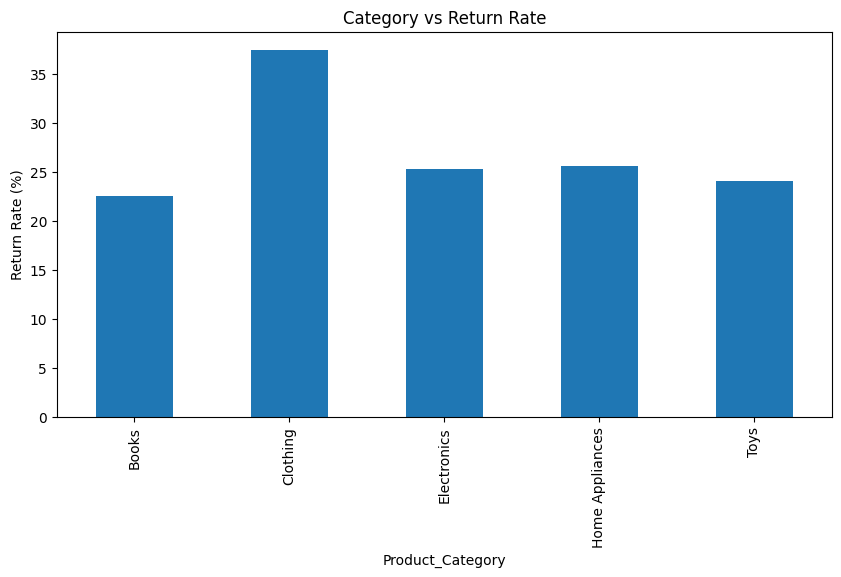

<Figure size 640x480 with 0 Axes>

In [84]:
category_return = (
    df.groupby(
        "Product_Category"
    )["Returned"]
    .mean()
    *100
)

print(category_return)

category_return.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Category vs Return Rate"
)

plt.ylabel(
    "Return Rate (%)"
)

plt.show()
plt.savefig("../images/category_vs_return_rate.png")

plt.show()

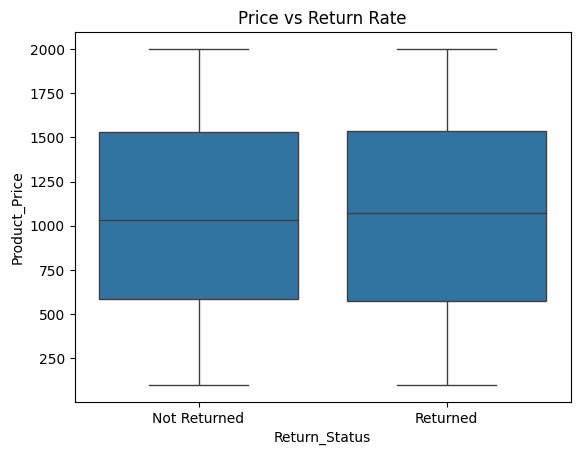

<Figure size 640x480 with 0 Axes>

In [85]:
sns.boxplot(
    x="Return_Status",
    y="Product_Price",
    data=df
)

plt.title(
    "Price vs Return Rate"
)

plt.show()
plt.savefig("../images/price_vs_return_rate.png")

plt.show()

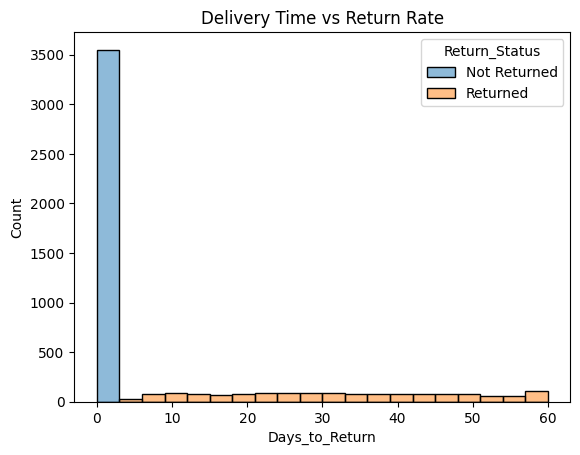

<Figure size 640x480 with 0 Axes>

In [86]:
sns.histplot(
    data=df,
    x="Days_to_Return",
    hue="Return_Status",
    bins=20
)

plt.title(
    "Delivery Time vs Return Rate"
)

plt.show()
plt.savefig("../images/Delivery Time_vs_return_rate.png")

plt.show()

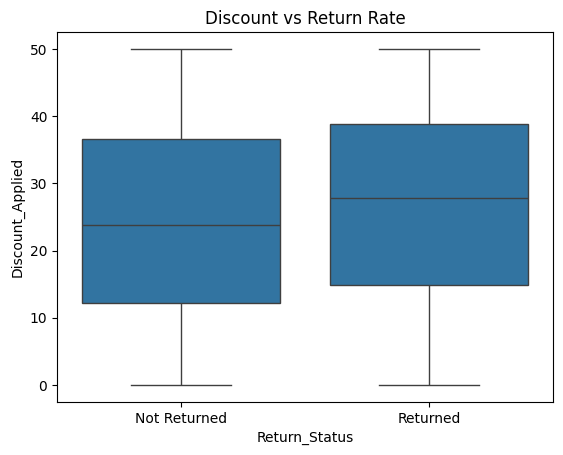

In [87]:
sns.boxplot(
    x="Return_Status",
    y="Discount_Applied",
    data=df
)

plt.title(
    "Discount vs Return Rate"
)

plt.show()

In [88]:
if "Customer_Rating" in df.columns:

    sns.boxplot(
        x="Return_Status",
        y="Customer_Rating",
        data=df
    )

    plt.show()

else:

    print(
        "Customer Rating column not available"
    )

Customer Rating column not available


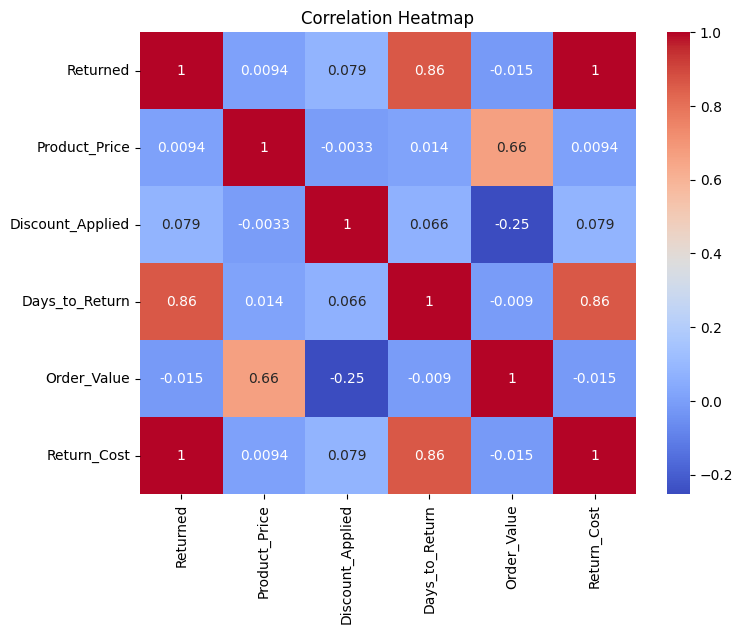

<Figure size 640x480 with 0 Axes>

In [89]:
corr = df[
[
"Returned",
"Product_Price",
"Discount_Applied",
"Days_to_Return",
"Order_Value",
"Return_Cost"
]
].corr()

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()
plt.savefig("../images/correlation_heatmap.png")

plt.show()

In [90]:
highest = (
category_return
.sort_values(
ascending=False
)
)

print(
highest
)

Product_Category
Clothing           37.429219
Home Appliances    25.630252
Electronics        25.241158
Toys               24.069149
Books              22.572178
Name: Returned, dtype: float64


In [91]:
discount_return = (
df.groupby(
"Return_Status"
)["Discount_Applied"]
.mean()
)

print(
discount_return
)

Return_Status
Not Returned    24.282566
Returned        26.796048
Name: Discount_Applied, dtype: float64


In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
customer_returns = (

df[df["Return_Status"]=="Returned"]

.groupby("User_ID")

.size()

.sort_values(
ascending=False
)

)

print(
customer_returns.head(10)
)

User_ID
USER1355    6
USER1684    5
USER0656    4
USER0505    4
USER0932    4
USER1287    4
USER1532    4
USER1616    4
USER1694    4
USER0161    4
dtype: int64


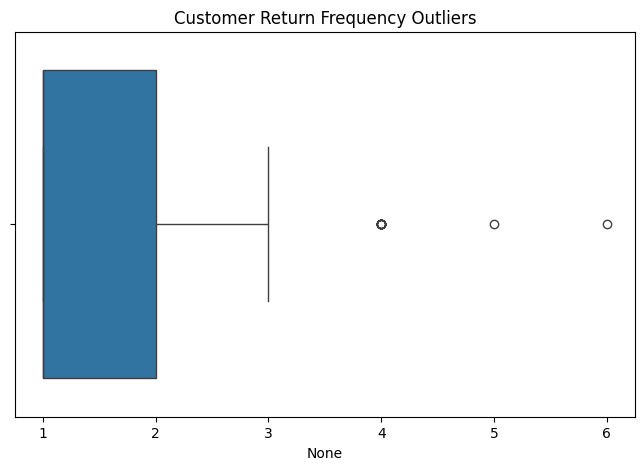

<Figure size 640x480 with 0 Axes>

In [94]:
plt.figure(
figsize=(8,5)
)

sns.boxplot(
x=customer_returns
)

plt.title(
"Customer Return Frequency Outliers"
)

plt.show()
plt.savefig("../images/customer return frequency outliers.png")

plt.show()

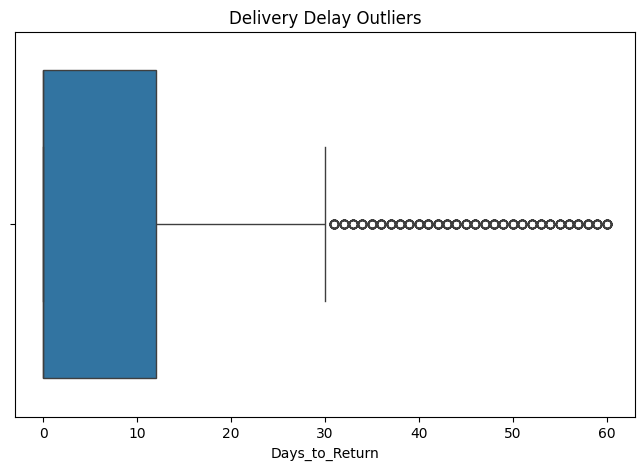

<Figure size 640x480 with 0 Axes>

In [95]:
plt.figure(
figsize=(8,5)
)

sns.boxplot(
x=df["Days_to_Return"]
)

plt.title(
"Delivery Delay Outliers"
)

plt.show()
plt.savefig("../images/Delivery Delay Outliers.png")

plt.show()

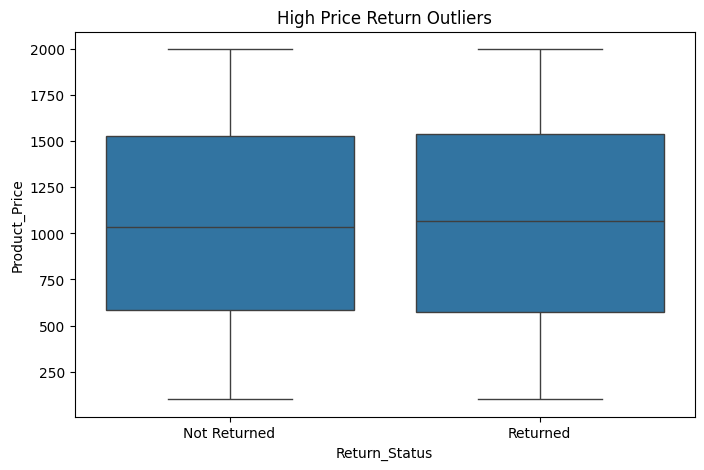

In [96]:
plt.figure(
figsize=(8,5)
)

sns.boxplot(
x="Return_Status",
y="Product_Price",
data=df
)

plt.title(
"High Price Return Outliers"
)

plt.show()

In [97]:
Q1 = df["Days_to_Return"].quantile(0.25)

Q3 = df["Days_to_Return"].quantile(0.75)

IQR = Q3 - Q1


lower_limit = Q1 - (1.5 * IQR)

upper_limit = Q3 + (1.5 * IQR)


outliers = df[

    (df["Days_to_Return"] < lower_limit)

    |

    (df["Days_to_Return"] > upper_limit)

]


print("Number of Outliers:")

print(len(outliers))


print("\nOutlier Records:")

print(outliers.head())

Number of Outliers:
741

Outlier Records:
    Order_ID Product_ID   User_ID  Order_Date Product_Category  Product_Price  \
6   ORD00006   PROD0203  USER0684  2022-12-02         Clothing        1486.38   
9   ORD00009   PROD0013  USER1831  2023-07-18         Clothing         841.45   
21  ORD00021   PROD0080  USER1065  2022-04-30             Toys         489.24   
42  ORD00042   PROD0492  USER0413  2024-07-08      Electronics        1917.35   
47  ORD00047   PROD0094  USER1491  2023-09-15         Clothing        1176.05   

    Order_Quantity  Discount_Applied Shipping_Method Payment_Method  ...  \
6                1             42.68         Express            COD  ...   
9                1             29.24        Next-Day    Credit Card  ...   
21               5             34.18         Express    Credit Card  ...   
42               4             36.66         Express     Debit Card  ...   
47               1              2.52        Standard     Debit Card  ...   

    Return_Rea

In [98]:
from scipy.stats import zscore

df["Z_Score"] = zscore(
    df["Days_to_Return"]
)

z_outliers = df[
    abs(
        df["Z_Score"]
    ) > 3
]


print(
    "Z Score Outliers:"
)

print(
    len(z_outliers)
)


print(
    z_outliers.head()
)

Z Score Outliers:
26
      Order_ID Product_ID   User_ID  Order_Date Product_Category  \
228   ORD00228   PROD0139  USER0262  2023-10-15  Home Appliances   
265   ORD00265   PROD0463  USER1836  2022-07-30         Clothing   
355   ORD00355   PROD0343  USER0769  2024-03-11         Clothing   
365   ORD00365   PROD0279  USER1583  2023-12-01         Clothing   
1098  ORD01098   PROD0483  USER0688  2022-11-30         Clothing   

      Product_Price  Order_Quantity  Discount_Applied Shipping_Method  \
228         1921.54               4              4.71        Next-Day   
265         1848.18               4             32.08         Express   
355          811.97               2             40.48         Express   
365          874.81               4             30.99        Standard   
1098         235.12               1             19.38         Express   

     Payment_Method  ...  Days_to_Return  Order_Value Return_Cost  \
228      Debit Card  ...              60  7324.141864         

In [99]:
from scipy.stats import ttest_ind

In [100]:
returned = df[
    df["Return_Status"] == "Returned"
]["Days_to_Return"]


not_returned = df[
    df["Return_Status"] == "Not Returned"
]["Days_to_Return"]

In [101]:
t_stat, p_value = ttest_ind(
    returned,
    not_returned,
    nan_policy="omit"
)

print("T Statistic:")

print(t_stat)

print("\nP Value:")

print(p_value)

T Statistic:
119.00260595400351

P Value:
0.0


In [102]:
if p_value < 0.05:

    print(
        "\nReject Null Hypothesis"
    )

    print(
        "Delivery delay significantly impacts return behavior"
    )

else:

    print(
        "\nFail to Reject Null Hypothesis"
    )

    print(
        "Delivery delay does not significantly impact return behavior"
    )


Reject Null Hypothesis
Delivery delay significantly impacts return behavior


In [103]:
if p_value < 0.05:

    print("""

Business Insight:

Customers experiencing longer delays
show statistically higher return behavior.

Recommendation:

Improve delivery timelines
to reduce return costs.

""")

else:

    print("""

Business Insight:

No strong evidence that
delivery delay affects returns.

Recommendation:

Investigate other factors such as
price, discount, or category.

""")



Business Insight:

Customers experiencing longer delays
show statistically higher return behavior.

Recommendation:

Improve delivery timelines
to reduce return costs.




In [104]:
high_return = (

df[df["Return_Status"]=="Returned"]

.groupby("User_ID")

.size()

.reset_index(
name="Return_Count"
)

)

high_return = high_return[

high_return["Return_Count"] > 1

]

print(
high_return.head()
)

     User_ID  Return_Count
4   USER0008             2
11  USER0022             2
14  USER0029             2
20  USER0041             2
26  USER0056             2


In [105]:
discount_customers = df[

df["Discount_Applied"] >

df["Discount_Applied"].median()

]

print(

discount_customers[
["User_ID","Discount_Applied"]
]

.head()

)

    User_ID  Discount_Applied
0  USER0195             30.46
1  USER1469             29.62
2  USER1812             47.80
4  USER0551             44.42
5  USER1533             42.65


In [106]:
delayed = df[

df["Days_to_Return"]

>

df["Days_to_Return"]

.quantile(0.75)

]

print(

delayed[
["User_ID","Days_to_Return"]
]

.head()

)

     User_ID  Days_to_Return
6   USER0684              48
9   USER1831              41
11  USER0576              27
12  USER1287              29
16  USER0631              28


In [107]:
if "Customer_Rating" in df.columns:

    low_rating = df[

    df["Customer_Rating"]

    <

    df["Customer_Rating"]

    .median()

    ]

    print(
    low_rating.head()
    )

else:

    print(
    "Customer Rating column not available"
    )

Customer Rating column not available


In [108]:
df["Customer_Group"] = "Normal"


df.loc[
df["Discount_Applied"] > 20,
"Customer_Group"
] = "Discount Driven"


df.loc[
df["Product_Price"] > 1000,
"Customer_Group"
] = "Premium"


df.loc[
df["Days_to_Return"] > 10,
"Customer_Group"
] = "Delayed Delivery"


df.loc[
df["Return_Status"]=="Returned",
"Customer_Group"
] = "High Return"


print(

df[
"Customer_Group"
]

.value_counts()

)

Customer_Group
Premium            1832
High Return        1450
Discount Driven    1019
Normal              699
Name: count, dtype: int64


In [109]:
analysis = (

df.groupby(
"Customer_Group"
)

[
[
"Product_Price",
"Discount_Applied",
"Days_to_Return",
"Order_Value"
]
]

.mean()

)

print(
analysis
)

                 Product_Price  Discount_Applied  Days_to_Return  Order_Value
Customer_Group                                                               
Discount Driven     568.574200         34.663700        0.000000  1137.965095
High Return        1062.323669         26.796048       31.738621  2323.718499
Normal              551.904149         10.144921        0.000000  1504.951833
Premium            1509.795999         23.902566        0.000000  3413.778800


In [110]:
correlation = (

df[
[
"Returned",
"Product_Price",
"Discount_Applied",
"Days_to_Return",
"Order_Value",
"Return_Cost"
]

].corr()

)

print(

correlation["Returned"]

.sort_values(
ascending=False
)

)

Returned            1.000000
Return_Cost         1.000000
Days_to_Return      0.859732
Discount_Applied    0.079042
Product_Price       0.009355
Order_Value        -0.015076
Name: Returned, dtype: float64


In [111]:
risky_categories = (

df.groupby(
"Product_Category"
)

["Returned"]

.mean()

*100

)

risky_categories = (

risky_categories

.sort_values(
ascending=False
)

)

print(
risky_categories
)

Product_Category
Clothing           37.429219
Home Appliances    25.630252
Electronics        25.241158
Toys               24.069149
Books              22.572178
Name: Returned, dtype: float64


In [112]:
delay_analysis = (

df.groupby(
"Return_Status"
)

["Days_to_Return"]

.mean()

)

print(
delay_analysis
)

Return_Status
Not Returned     0.000000
Returned        31.738621
Name: Days_to_Return, dtype: float64


In [113]:
intervention = (

df[
"Customer_Group"
]

.value_counts()

)

print(
intervention
)

Customer_Group
Premium            1832
High Return        1450
Discount Driven    1019
Normal              699
Name: count, dtype: int64


In [114]:
import sys

sys.path.append("../src")

In [115]:
from analysis_functions import *

In [116]:
print(
calculate_return_percentage(df)
)

29.0
